# Uso y confianza en la IA en el trabajo, enriquecido con desarrollo, desigualdad, demografía y confianza institucional

Punto de partida: figura 9.1.10 del *Stanford AI Index Report 2026* (% que usa IA en el trabajo vs. % que confía en la IA en el trabajo, por país).

Variables añadidas:
- **IDH** — PNUD, *Human Development Report 2025* (datos 2023)
- **GINI** — Banco Mundial / World Inequality Database, año más reciente disponible por país
- **GNI per cápita (PPP $)** — PNUD, misma tabla del IDH (usado como PIB per cápita aislado)
- **Edad mediana** — World Population Review / UN World Population Prospects, 2024
- **Confianza institucional generalizada** — Edelman Trust Barometer 2026 (cobertura parcial: 24 de 47 países)

Requisitos: `pandas`, `numpy`, `scipy`, `matplotlib`, `statsmodels`, `adjustText`
(`pip install adjustText statsmodels --break-system-packages` si hace falta).

In [1]:
!pip3 install adjustText --break-system-packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from adjustText import adjust_text
import scienceplots
#plt.style.use('science')
pd.set_option("display.width", 120)
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10.5})

## 1. Datos

Dataset completo embebido (47 países; la fila "Global" del CSV original del AI Index se excluye porque no tiene IDH/GINI propios).

In [3]:
data_csv = """country,using_ai_at_work,trust_ai_at_work,hdi,gini,gni_per_capita,median_age,edelman_trust
India,91,81,0.685,25.5,9047,29.8,74
China,88,73,0.797,26.0,22029,40.2,80
Nigeria,85,81,0.560,33.9,5569,19.3,72
United Arab Emirates,84,69,0.940,26.4,71142,35.8,80
Egypt,84,79,0.754,28.5,16218,24.4,
Saudi Arabia,82,69,0.900,45.6,50299,32.4,73
Costa Rica,76,55,0.833,45.8,23417,35.5,
Brazil,75,60,0.786,51.6,18011,35.1,56
South Africa,74,64,0.741,63.0,13694,30.4,54
Turkey,69,62,0.853,44.5,34507,34.0,
Norway,67,61,0.970,26.5,112710,40.8,
Switzerland,65,54,0.970,33.8,81949,44.2,
Colombia,65,51,0.788,53.9,18666,32.7,49
Singapore,64,60,0.946,45.8,111239,39.4,64
Mexico,64,53,0.789,43.5,21813,30.8,57
Argentina,62,52,0.865,42.4,25876,33.3,50
Chile,58,50,0.878,43.0,28047,36.9,
Poland,54,49,0.906,28.5,42218,42.9,
Lithuania,54,32,0.895,36.0,41916,45.1,
South Korea,54,46,0.937,32.9,49726,45.5,46
Latvia,53,40,0.889,34.0,37998,45.5,
Estonia,53,52,0.905,30.7,40881,45.0,
Denmark,53,51,0.962,29.9,76008,42.2,
USA,52,48,0.938,41.8,73650,38.9,47
Romania,52,48,0.845,29.8,39374,45.5,
Spain,50,53,0.918,33.4,46008,46.8,45
Slovenia,50,42,0.931,24.7,46361,46.3,
Portugal,49,44,0.890,33.9,41064,46.4,
Italy,49,42,0.915,34.3,52389,48.4,50
Austria,49,43,0.930,31.2,63479,44.9,
Australia,49,45,0.958,34.3,58277,38.1,54
United Kingdom,48,48,0.946,32.4,54372,40.8,44
Ireland,47,43,0.949,29.0,90885,40.2,47
Finland,47,33,0.948,27.4,57068,43.3,
Israel,46,57,0.919,37.9,48050,30.1,
Sweden,44,39,0.959,29.3,66102,41.1,52
Japan,44,31,0.925,32.3,47775,49.9,38
France,44,41,0.920,31.8,55060,42.6,42
Belgium,44,48,0.951,26.8,63582,42.0,
Greece,43,50,0.908,33.4,35761,46.5,
Canada,43,41,0.939,29.9,54688,42.6,52
Netherlands,42,42,0.955,25.7,68344,42.2,58
Germany,42,43,0.959,32.4,64053,46.8,44
New Zealand,41,39,0.938,33.9,47260,37.9,
Hungary,39,55,0.870,30.2,37236,44.8,
Slovak Republic,35,39,0.880,23.8,36793,42.8,
Czech Republic,33,39,0.915,25.7,45889,44.2,
"""

import io
df = pd.read_csv(io.StringIO(data_csv))
df["log_gni"] = np.log(df.gni_per_capita)
print(df.shape)
df.head()

(47, 9)


,country,using_ai_at_work,trust_ai_at_work,hdi,gini,gni_per_capita,median_age,edelman_trust,log_gni
0,India,91,81,0.685,25.5,9047,29.8,74.0,9.110188
1,China,88,73,0.797,26.0,22029,40.2,80.0,10.000115
2,Nigeria,85,81,0.560,33.9,5569,19.3,72.0,8.624971
3,United Arab Emirates,84,69,0.940,26.4,71142,35.8,80.0,11.172433
4,Egypt,84,79,0.754,28.5,16218,24.4,NaN,9.693877


## 2. Figura inicial: uso vs. confianza, coloreado por IDH y dimensionado por GINI

Esta fue la primera versión enriquecida: parte de la idea de que el color (IDH) y el tamaño (GINI) son
las variables "más interesantes" a primera vista para añadir a un scatter de dos variables. Más abajo
veremos, con la regresión, si esa intuición se sostiene.

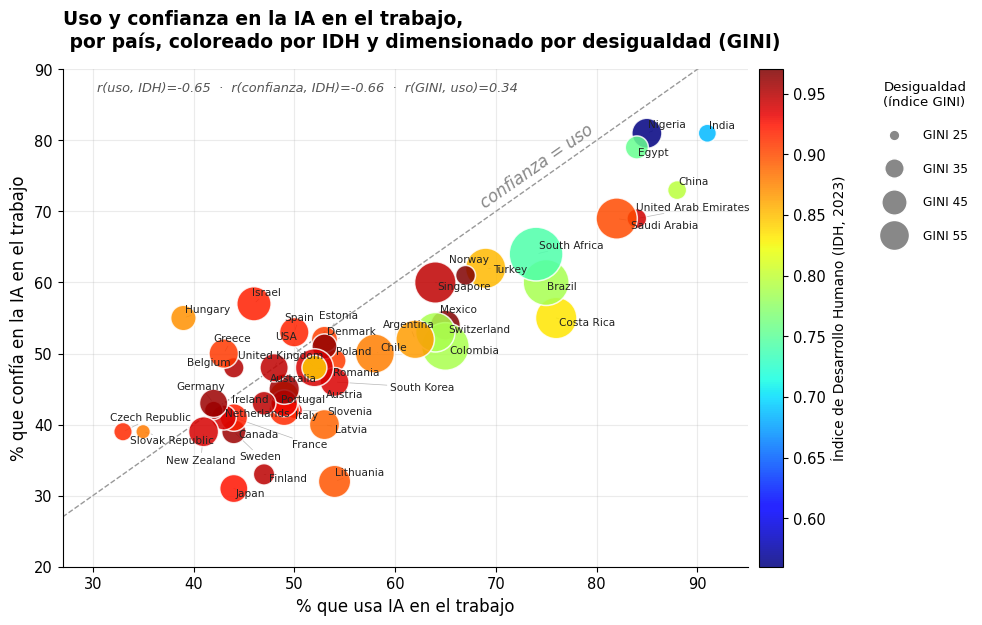

In [4]:
fig, ax = plt.subplots(figsize=(11.5, 6.5))

cmap = plt.get_cmap("jet")
norm = mpl.colors.Normalize(vmin=df.hdi.min(), vmax=df.hdi.max())

size_min, size_max = 110, 1500
g_min, g_max = df.gini.min(), df.gini.max()
sizes = size_min + (df.gini - g_min) / (g_max - g_min) * (size_max - size_min)

scatter = ax.scatter(
    df.using_ai_at_work, df.trust_ai_at_work,
    s=sizes, c=df.hdi, cmap=cmap, norm=norm,
    alpha=0.85, edgecolors="white", linewidths=1.1, zorder=3
)

lims = [27, 95]
ax.plot(lims, lims, ls="--", lw=1, color="#999999", zorder=1)
ax.text(80, 70, "confianza = uso", fontsize=12, color="#888888",
        rotation=35, ha="right", va="bottom", style="italic")

texts = [ax.text(row.using_ai_at_work, row.trust_ai_at_work, row.country, fontsize=7.6, zorder=4, color="#222222")
         for _, row in df.iterrows()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="#999999", lw=0.5, alpha=0.7),
            expand=(1.25, 1.6))

ax.set_xlabel("% que usa IA en el trabajo", fontsize=12)
ax.set_ylabel("% que confía en la IA en el trabajo", fontsize=12)
ax.set_xlim(27, 95); ax.set_ylim(20, 90)
ax.grid(True, alpha=0.25, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

r1, _ = stats.pearsonr(df.using_ai_at_work, df.hdi)
r2, _ = stats.pearsonr(df.trust_ai_at_work, df.hdi)
r3, _ = stats.pearsonr(df.gini, df.using_ai_at_work)

ax.set_title(
    "Uso y confianza en la IA en el trabajo, \n por país, coloreado por IDH y dimensionado por desigualdad (GINI)",
    fontsize=13.5, fontweight="bold", pad=16, loc="left"
)
ax.text(0.05, 0.955,
    f"r(uso, IDH)={r1:.2f}  ·  r(confianza, IDH)={r2:.2f}  ·  r(GINI, uso)={r3:.2f}",
    transform=ax.transAxes, fontsize=9.3, color="#555555", style="italic")

cbar = fig.colorbar(scatter, ax=ax, pad=0.015, fraction=0.045)
cbar.set_label("Índice de Desarrollo Humano (IDH, 2023)", fontsize=10)

gini_ref = [25, 35, 45, 55]
legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#888888", markeredgecolor="white",
           markersize=np.sqrt(size_min + (g - g_min)/(g_max-g_min)*(size_max-size_min)) * 0.62, label=f"GINI {g}")
    for g in gini_ref
]
ax.legend(handles=legend_handles, title="Desigualdad\n(índice GINI)", loc="upper left",
          bbox_to_anchor=(1.18, 1.0), frameon=False, labelspacing=1.7, handletextpad=1.4,
          title_fontsize=9.5, fontsize=8.7)

plt.tight_layout(rect=[0, 0.02, 0.88, 1])
plt.savefig("ai_trust_use_hdi_gini.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Correlaciones entre predictores y con las variables de interés

In [5]:
predictors_full = ["hdi", "gini", "median_age", "log_gni"]
corr = df[predictors_full + ["using_ai_at_work", "trust_ai_at_work"]].corr(method="pearson").round(2)
corr

,hdi,gini,median_age,log_gni,using_ai_at_work,trust_ai_at_work
hdi,1.00,-0.32,0.71,0.95,-0.65,-0.66
gini,-0.32,1.00,-0.42,-0.32,0.34,0.20
median_age,0.71,-0.42,1.00,0.64,-0.69,-0.74
log_gni,0.95,-0.32,0.64,1.00,-0.55,-0.54
using_ai_at_work,-0.65,0.34,-0.69,-0.55,1.00,0.86
trust_ai_at_work,-0.66,0.20,-0.74,-0.54,0.86,1.00


## 4. Diagnóstico de colinealidad (VIF)

IDH y log(GNI per cápita) están muy correlacionados entre sí (r≈0.95) porque el GNI es un insumo directo
del cálculo del IDH. Eso infla la varianza de sus coeficientes individuales en la regresión múltiple — hay
que leer esos dos coeficientes con cautela.

In [6]:
X = sm.add_constant(df[predictors_full])
vif = pd.DataFrame({
    "variable": predictors_full,
    "VIF": [variance_inflation_factor(X.values, i+1) for i in range(len(predictors_full))]
})
vif

,variable,VIF
0,hdi,13.808758
1,gini,1.231989
2,median_age,2.285897
3,log_gni,11.650242


## 5. Regresiones múltiples (N=47, sin Edelman)

Coeficientes estandarizados (z-score) para que sean comparables entre variables de escalas muy distintas.

In [7]:
def z(s):
    return (s - s.mean()) / s.std()

def run_model(dv, predictors, data, label):
    sub = data.dropna(subset=predictors + [dv]).copy()
    Xz = sm.add_constant(sub[predictors].apply(z))
    y = sub[dv]
    model = sm.OLS(y, Xz).fit()
    print(f"\n{label}  (N={len(sub)})")
    print(model.summary2().tables[1].round(3))
    print(f"R² = {model.rsquared:.3f}   R² ajustado = {model.rsquared_adj:.3f}   F p-valor = {model.f_pvalue:.4f}")
    return model

m_trust = run_model("trust_ai_at_work", predictors_full, df,
                     "MODELO A: Confianza en IA ~ IDH + GINI + Edad mediana + log(GNI pc)")
m_use   = run_model("using_ai_at_work", predictors_full, df,
                     "MODELO B: Uso de IA ~ IDH + GINI + Edad mediana + log(GNI pc)")


MODELO A: Confianza en IA ~ IDH + GINI + Edad mediana + log(GNI pc)  (N=47)
             Coef.  Std.Err.       t  P>|t|  [0.025  0.975]
const       51.000     1.128  45.206  0.000  48.723  53.277
hdi        -12.019     4.238  -2.836  0.007 -20.570  -3.467
gini        -1.368     1.266  -1.081  0.286  -3.922   1.186
median_age  -6.557     1.724  -3.803  0.000 -10.036  -3.077
log_gni      8.560     3.892   2.199  0.033   0.705  16.415
R² = 0.637   R² ajustado = 0.603   F p-valor = 0.0000

MODELO B: Uso de IA ~ IDH + GINI + Edad mediana + log(GNI pc)  (N=47)
             Coef.  Std.Err.       t  P>|t|  [0.025  0.975]
const       56.511     1.529  36.967  0.000  53.426  59.596
hdi        -14.074     5.742  -2.451  0.018 -25.662  -2.487
gini         1.079     1.715   0.629  0.533  -2.382   4.541
median_age  -5.752     2.336  -2.462  0.018 -10.467  -1.038
log_gni      9.087     5.274   1.723  0.092  -1.557  19.730
R² = 0.560   R² ajustado = 0.518   F p-valor = 0.0000


## 6. Confianza institucional generalizada (Edelman Trust Barometer)

⚠️ Edelman solo cubre 24 de los 47 países de esta muestra (no incluye, sobre todo, economías pequeñas
europeas). Cualquier modelo con esta variable trabaja sobre una submuestra distinta — más sesgada hacia
economías grandes — así que no es directamente comparable con los modelos de N=47 de arriba.

Primero, la relación bivariada; después, un test jerárquico: ¿la confianza institucional añade poder
explicativo *más allá* del IDH, o simplemente lo sustituye?

In [8]:
sub = df.dropna(subset=["edelman_trust"]).copy()
print(f"N submuestra con Edelman = {len(sub)}")

r, p = stats.pearsonr(sub.edelman_trust, sub.trust_ai_at_work)
print(f"r(Edelman, confianza-IA) = {r:.3f}  p={p:.5f}  R²={r**2:.3f}")

r2, p2 = stats.pearsonr(sub.hdi, sub.trust_ai_at_work)
print(f"r(IDH, confianza-IA) en esta submuestra (N={len(sub)}) = {r2:.3f}  p={p2:.4f}")

N submuestra con Edelman = 24
r(Edelman, confianza-IA) = 0.850  p=0.00000  R²=0.723
r(IDH, confianza-IA) en esta submuestra (N=24) = -0.732  p=0.0000


In [9]:
# Paso 1: confianza ~ IDH
X1 = sm.add_constant(z(sub.hdi))
m1 = sm.OLS(sub.trust_ai_at_work, X1).fit()
print(f"Paso 1 (solo IDH): R²={m1.rsquared:.3f}  coef={m1.params['hdi']:.2f}  p={m1.pvalues['hdi']:.4f}")

# Paso 2: confianza ~ IDH + Edelman
X2 = sm.add_constant(pd.DataFrame({"hdi": z(sub.hdi), "edelman_trust": z(sub.edelman_trust)}))
m2 = sm.OLS(sub.trust_ai_at_work, X2).fit()
print("\nPaso 2 (IDH + Edelman):")
print(m2.summary2().tables[1].round(3))
print(f"R²={m2.rsquared:.3f}  (vs {m1.rsquared:.3f} solo con IDH)")

from scipy.stats import f as fdist
n = len(sub); p_full, p_reduced = 2, 1
f_stat = ((m2.rsquared - m1.rsquared) / (p_full - p_reduced)) / ((1 - m2.rsquared) / (n - p_full - 1))
p_val = 1 - fdist.cdf(f_stat, p_full - p_reduced, n - p_full - 1)
print(f"\nΔR² al añadir Edelman sobre IDH: {m2.rsquared - m1.rsquared:.3f}  F={f_stat:.2f}  p={p_val:.5f}")

Paso 1 (solo IDH): R²=0.536  coef=-9.98  p=0.0000

Paso 2 (IDH + Edelman):
                Coef.  Std.Err.       t  P>|t|  [0.025  0.975]
const          53.125     1.050  50.610    0.0  50.942  55.308
hdi            -5.893     1.208  -4.880    0.0  -8.404  -3.382
edelman_trust   8.883     1.208   7.356    0.0   6.372  11.395
R²=0.870  (vs 0.536 solo con IDH)

ΔR² al añadir Edelman sobre IDH: 0.335  F=54.11  p=0.00000


## 7. Panel de pequeños múltiplos: confianza en IA vs. cada predictor

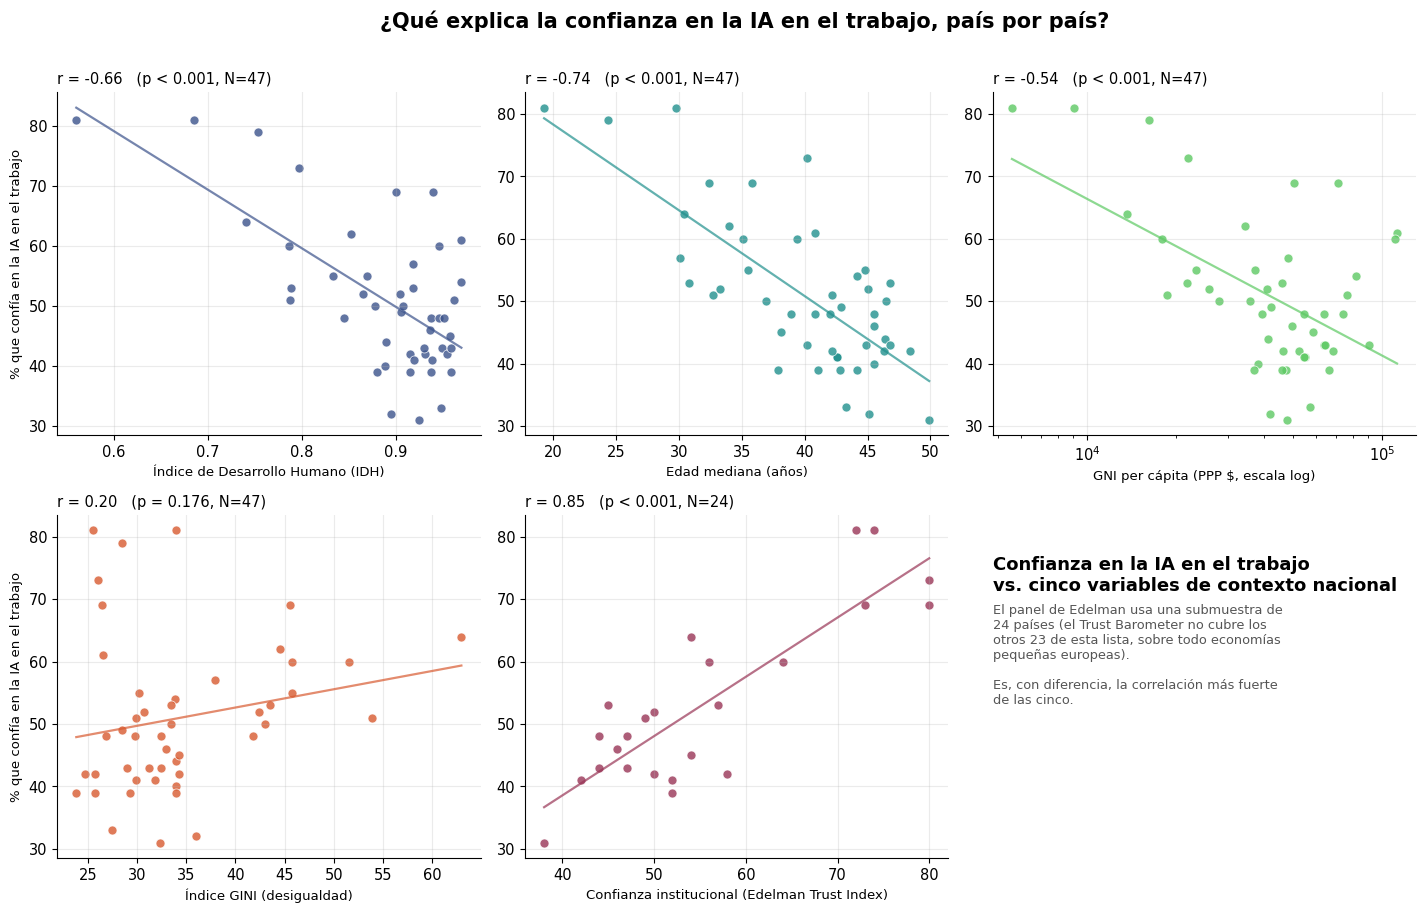

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

panels = [
    ("hdi", "Índice de Desarrollo Humano (IDH)", df, "#3b528b"),
    ("median_age", "Edad mediana (años)", df, "#21908d"),
    ("gni_per_capita", "GNI per cápita (PPP $, escala log)", df, "#5dc963"),
    ("gini", "Índice GINI (desigualdad)", df, "#D85A30"),
    ("edelman_trust", "Confianza institucional (Edelman Trust Index)", df.dropna(subset=["edelman_trust"]), "#993556"),
]

for ax, (col, label, data, color) in zip(axes, panels):
    x = data[col]; y = data["trust_ai_at_work"]
    logx = col == "gni_per_capita"
    xx = np.log(x) if logx else x
    r, p = stats.pearsonr(xx, y)
    ax.scatter(x, y, s=42, color=color, alpha=0.8, edgecolors="white", linewidths=0.6)
    coef = np.polyfit(xx, y, 1)
    xs = np.linspace(xx.min(), xx.max(), 50)
    ys = np.polyval(coef, xs)
    xs_plot = np.exp(xs) if logx else xs
    ax.plot(xs_plot, ys, color=color, lw=1.6, alpha=0.7)
    if logx:
        ax.set_xscale("log")
    n = len(data)
    sig = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
    ax.set_title(f"r = {r:.2f}   ({sig}, N={n})", fontsize=10.5, loc="left")
    ax.set_xlabel(label, fontsize=9.5)
    if ax in (axes[0], axes[3]):
        ax.set_ylabel("% que confía en la IA en el trabajo", fontsize=9.5)
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

axes[5].axis("off")
axes[5].text(0.0, 0.78, "Confianza en la IA en el trabajo\nvs. cinco variables de contexto nacional",
             fontsize=13, fontweight="bold", transform=axes[5].transAxes)
axes[5].text(0.0, 0.45,
    "El panel de Edelman usa una submuestra de\n24 países (el Trust Barometer no cubre los\n"
    "otros 23 de esta lista, sobre todo economías\npequeñas europeas).\n\n"
    "Es, con diferencia, la correlación más fuerte\nde las cinco.",
    fontsize=9.3, color="#555555", transform=axes[5].transAxes)

fig.suptitle("¿Qué explica la confianza en la IA en el trabajo, país por país?",
              fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("panel_predictores_confianza.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Coeficientes estandarizados: modelo de 4 predictores vs. modelo reducido (IDH + Edelman)

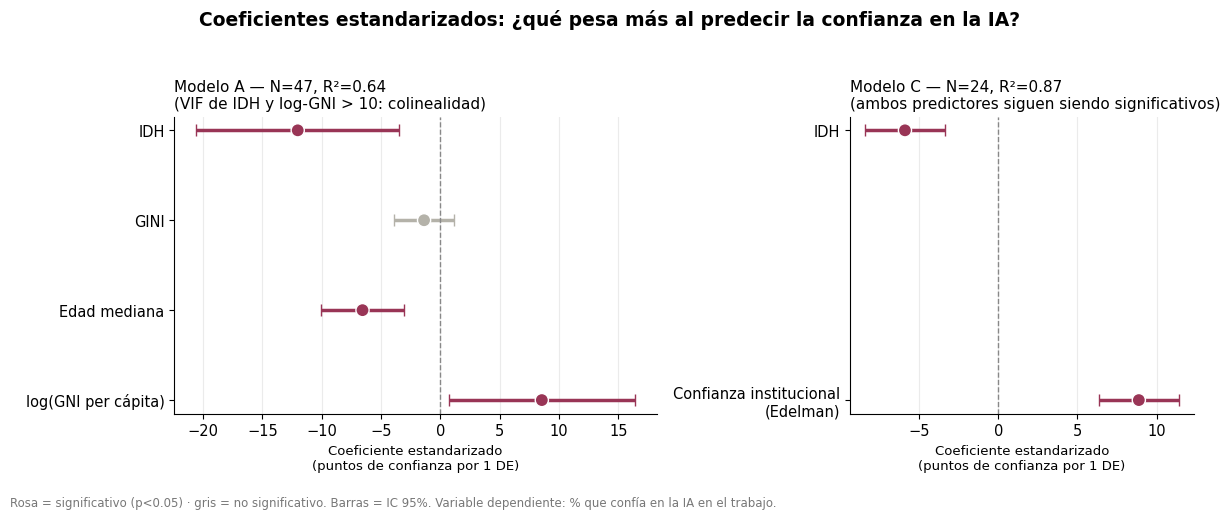

In [11]:
predsA = predictors_full
XA = sm.add_constant(df[predsA].apply(z))
mA = sm.OLS(df.trust_ai_at_work, XA).fit()

predsC = ["hdi", "edelman_trust"]
XC = sm.add_constant(pd.DataFrame({"hdi": z(sub.hdi), "edelman_trust": z(sub.edelman_trust)}))
mC = sm.OLS(sub.trust_ai_at_work, XC).fit()

labels_A = ["IDH", "GINI", "Edad mediana", "log(GNI per cápita)"]
labels_C = ["IDH", "Confianza institucional\n(Edelman)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.4, 1]})

ax = axes[0]
coefs = mA.params[predsA].values
ci = mA.conf_int().loc[predsA].values
errs = (ci[:, 1] - ci[:, 0]) / 2
ypos = np.arange(len(predsA))[::-1]
colors = ["#993556" if p < 0.05 else "#B4B2A9" for p in mA.pvalues[predsA]]
for xi, yi, ei, ci_ in zip(coefs, ypos, errs, colors):
    ax.errorbar([xi], [yi], xerr=[ei], fmt="none", ecolor=ci_, elinewidth=2.5, capsize=4, zorder=2)
ax.scatter(coefs, ypos, c=colors, s=90, zorder=3, edgecolors="white")
ax.axvline(0, color="#888888", lw=1, ls="--")
ax.set_yticks(ypos); ax.set_yticklabels(labels_A, fontsize=10.5)
ax.set_xlabel("Coeficiente estandarizado\n(puntos de confianza por 1 DE)", fontsize=9.5)
ax.set_title(f"Modelo A — N=47, R²={mA.rsquared:.2f}\n(VIF de IDH y log-GNI > 10: colinealidad)", fontsize=11, loc="left")
ax.grid(alpha=0.25, axis="x"); ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
coefs = mC.params[predsC].values
ci = mC.conf_int().loc[predsC].values
errs = (ci[:, 1] - ci[:, 0]) / 2
ypos = np.arange(len(predsC))[::-1]
colors = ["#993556" if p < 0.05 else "#B4B2A9" for p in mC.pvalues[predsC]]
for xi, yi, ei, ci_ in zip(coefs, ypos, errs, colors):
    ax.errorbar([xi], [yi], xerr=[ei], fmt="none", ecolor=ci_, elinewidth=2.5, capsize=4, zorder=2)
ax.scatter(coefs, ypos, c=colors, s=90, zorder=3, edgecolors="white")
ax.axvline(0, color="#888888", lw=1, ls="--")
ax.set_yticks(ypos); ax.set_yticklabels(labels_C, fontsize=10.5)
ax.set_xlabel("Coeficiente estandarizado\n(puntos de confianza por 1 DE)", fontsize=9.5)
ax.set_title(f"Modelo C — N=24, R²={mC.rsquared:.2f}\n(ambos predictores siguen siendo significativos)", fontsize=11, loc="left")
ax.grid(alpha=0.25, axis="x"); ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Coeficientes estandarizados: ¿qué pesa más al predecir la confianza en la IA?",
              fontsize=13.5, fontweight="bold", y=1.04)
fig.text(0, -0.04,
    "Rosa = significativo (p<0.05) · gris = no significativo. Barras = IC 95%. "
    "Variable dependiente: % que confía en la IA en el trabajo.",
    fontsize=8.5, color="#777777")
plt.tight_layout()
plt.savefig("coeficientes_regresion.png", dpi=300, bbox_inches="tight")
plt.show()

## Notas y limitaciones

- **Fuente uso/confianza**: Stanford HAI, *AI Index Report 2026*, fig. 9.1.10.
- **IDH y GNI per cápita**: PNUD, *Human Development Report 2025* (datos 2023), tabla estadística oficial.
- **GINI**: Banco Mundial / World Inequality Database — el año de referencia varía por país (2014–2024), ya que no todos los países tienen encuestas recientes. Para Nueva Zelanda y Arabia Saudita se usaron estimaciones de fuentes secundarias (Wikipedia/World Economics) ante la ausencia de dato reciente del Banco Mundial.
- **Edad mediana**: World Population Review / UN World Population Prospects 2024.
- **Edelman Trust Barometer 2026**: cubre 28 mercados; de ellos, 24 coinciden con esta muestra de 47 países. Los modelos que usan esta variable trabajan sobre N=24, sesgado hacia economías grandes — no son directamente comparables con los modelos de N=47.
- **Colinealidad**: IDH y log(GNI per cápita) tienen VIF>10 en el modelo de 4 predictores; sus coeficientes individuales deben interpretarse con cautela en ese modelo específico (el modelo reducido IDH+Edelman es más estable).
- Todas las correlaciones son de Pearson; no se ha hecho ningún ajuste por comparaciones múltiples.